## Objetivos

- validar schema, tipos, duplicidades e valores ausentes;
- medir a distribuição da variável-alvo;
- comparar atributos numéricos e categóricos com o churn;
- identificar colunas constantes, identificadores e vazamento de informação;
- registrar decisões para pré-processamento e validação.

In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from projeto_ml.data import TARGET_COLUMN, load_telco_churn  # noqa: E402

DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "Telco_customer_churn(Telco_Churn).csv"
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 40)

In [2]:
df = load_telco_churn(DATASET_PATH)
display(df.head())
display(pd.DataFrame({"linhas": [df.shape[0]], "colunas": [df.shape[1]]}))

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


,linhas,colunas
0,7043,33


In [3]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
print(df.describe())

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   CustomerID         7043 non-null   object  
 1   Count              7043 non-null   int64   
 2   Country            7043 non-null   category
 3   State              7043 non-null   category
 4   City               7043 non-null   object  
 5   Zip Code           7043 non-null   int64   
 6   Lat Long           7043 non-null   object  
 7   Latitude           7043 non-null   float64 
 8   Longitude          7043 non-null   float64 
 9   Gender             7043 non-null   category
 10  Senior Citizen     7043 non-null   category
 11  Partner            7043 non-null   category
 12  Dependents         7043 non-null   category
 13  Tenure Months      7043 non-null   int64   
 14  Phone Service      7043 non-null   category
 15  Multiple Lines  

## Qualidade dos dados

O arquivo usa ponto e vírgula como separador e vírgula como separador decimal. `Total Charges` contém espaços em branco para clientes com zero meses de permanência.

In [3]:
quality = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_pct": df.isna().mean().mul(100).round(2),
    "unicos": df.nunique(dropna=False),
}).sort_values(["nulos", "unicos"], ascending=[False, True])

display(quality)
display(pd.DataFrame({
    "linhas_duplicadas": [int(df.duplicated().sum())],
    "customer_id_duplicados": [int(df["CustomerID"].duplicated().sum())],
}))
missing_total_charges_columns = [
    "CustomerID", "Tenure Months", "Monthly Charges", "Total Charges"
]
display(df.loc[df["Total Charges"].isna(), missing_total_charges_columns])

,tipo,nulos,nulos_pct,unicos
Churn Reason,object,5174,73.46,21
Total Charges,float64,11,0.16,6531
Count,int64,0,0.00,1
Country,object,0,0.00,1
State,object,0,0.00,1
Gender,object,0,0.00,2
Senior Citizen,object,0,0.00,2
Partner,object,0,0.00,2
Dependents,object,0,0.00,2
Phone Service,object,0,0.00,2


,linhas_duplicadas,customer_id_duplicados
0,0,0


,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.55,NaN
2438,3115-CZMZD,0,20.25,NaN
2568,5709-LVOEQ,0,80.85,NaN
2667,4367-NUYAO,0,25.75,NaN
2856,1371-DWPAZ,0,56.05,NaN
4331,7644-OMVMY,0,19.85,NaN
4687,3213-VVOLG,0,25.35,NaN
5104,2520-SGTTA,0,20.00,NaN
5719,2923-ARZLG,0,19.70,NaN
6772,4075-WKNIU,0,73.35,NaN


## Distribuição do alvo

A classe positiva é minoritária. O treinamento deverá usar divisão estratificada e métricas além de acurácia, como recall, F1 e ROC-AUC/PR-AUC.

,clientes,percentual
Churn Value,,
Não,5174,73.46
Sim,1869,26.54


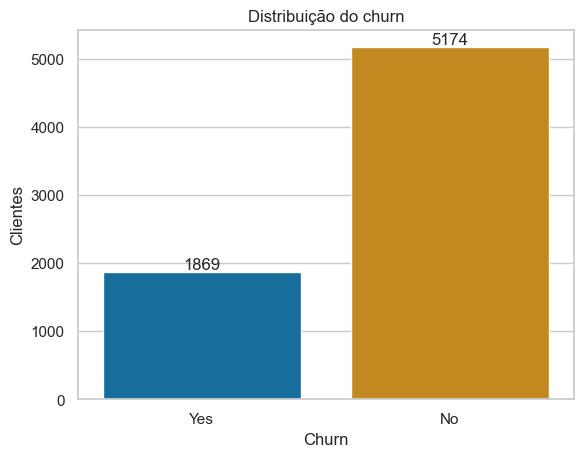

In [4]:
target_summary = (
    df[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename(index={0: "Não", 1: "Sim"})
    .to_frame("clientes")
)
target_summary["percentual"] = target_summary["clientes"].div(len(df)).mul(100).round(2)
display(target_summary)

ax = sns.countplot(data=df, x="Churn Label", hue="Churn Label", legend=False)
ax.set(title="Distribuição do churn", xlabel="Churn", ylabel="Clientes")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

#TESTE#
        


In [ ]:
corr_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Value"
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[corr_features].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlação entre variáveis numéricas")
plt.show()

## Atributos numéricos

As distribuições ajudam a observar diferenças de permanência, cobrança mensal e cobrança total entre clientes que saíram e permaneceram.

Tenure Months               Monthly Charges                \
                     mean median    std            mean median    std   
Churn Label                                                             
No                  37.57   38.0  24.11           61.27  64.43  31.09   
Yes                 17.98   10.0  19.53           74.44  79.65  24.67   

            Total Charges                       CLTV                   
                     mean   median      std     mean  median      std  
Churn Label                                                            
No                2555.34  1683.60  2329.46  4490.92  4620.0  1167.70  
Yes               1531.80   703.55  1890.82  4149.41  4238.0  1189.37

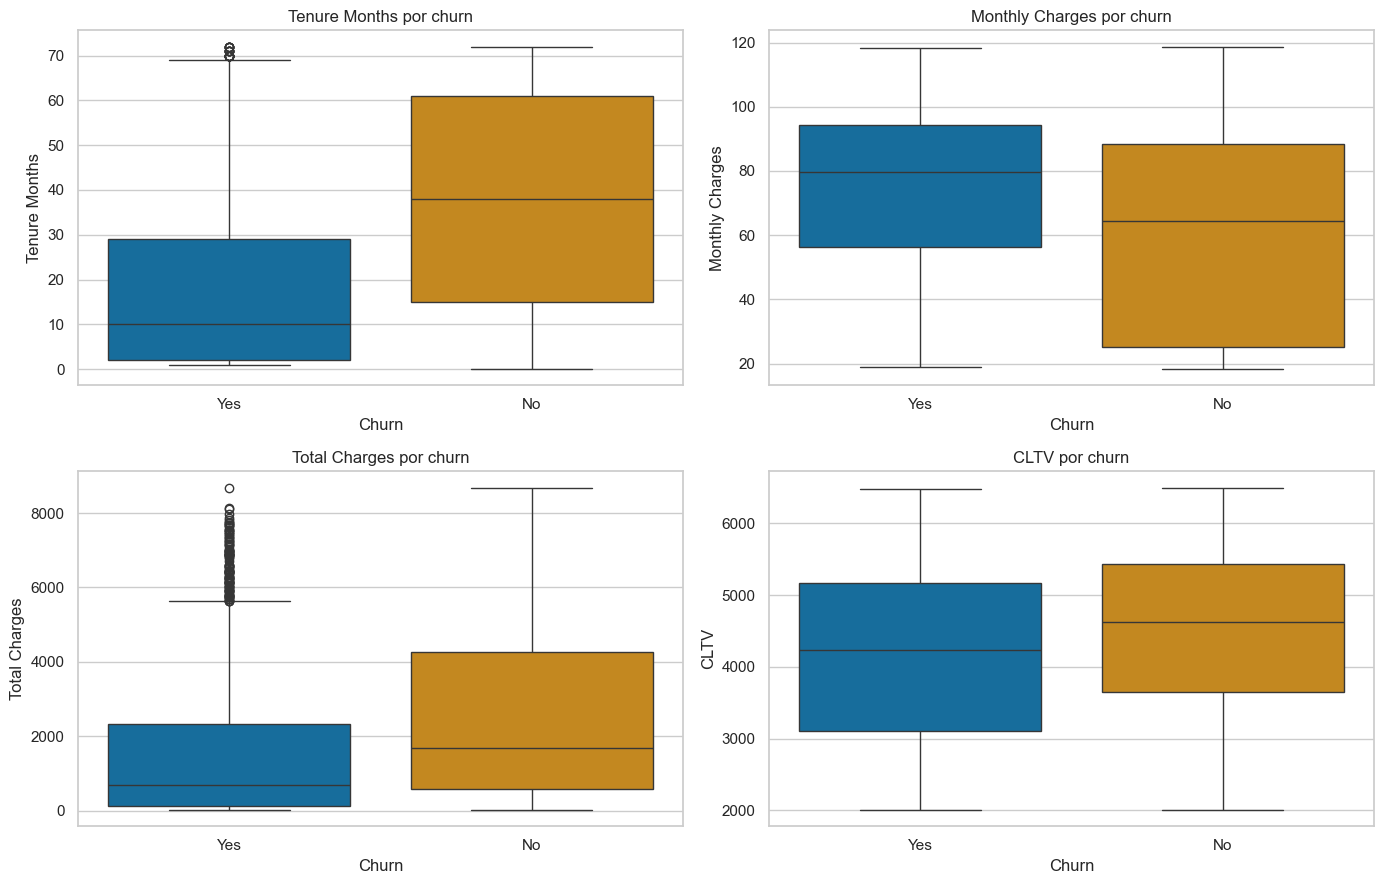

## Atributos categóricos

A taxa de churn é comparada nas categorias com maior relevância operacional.

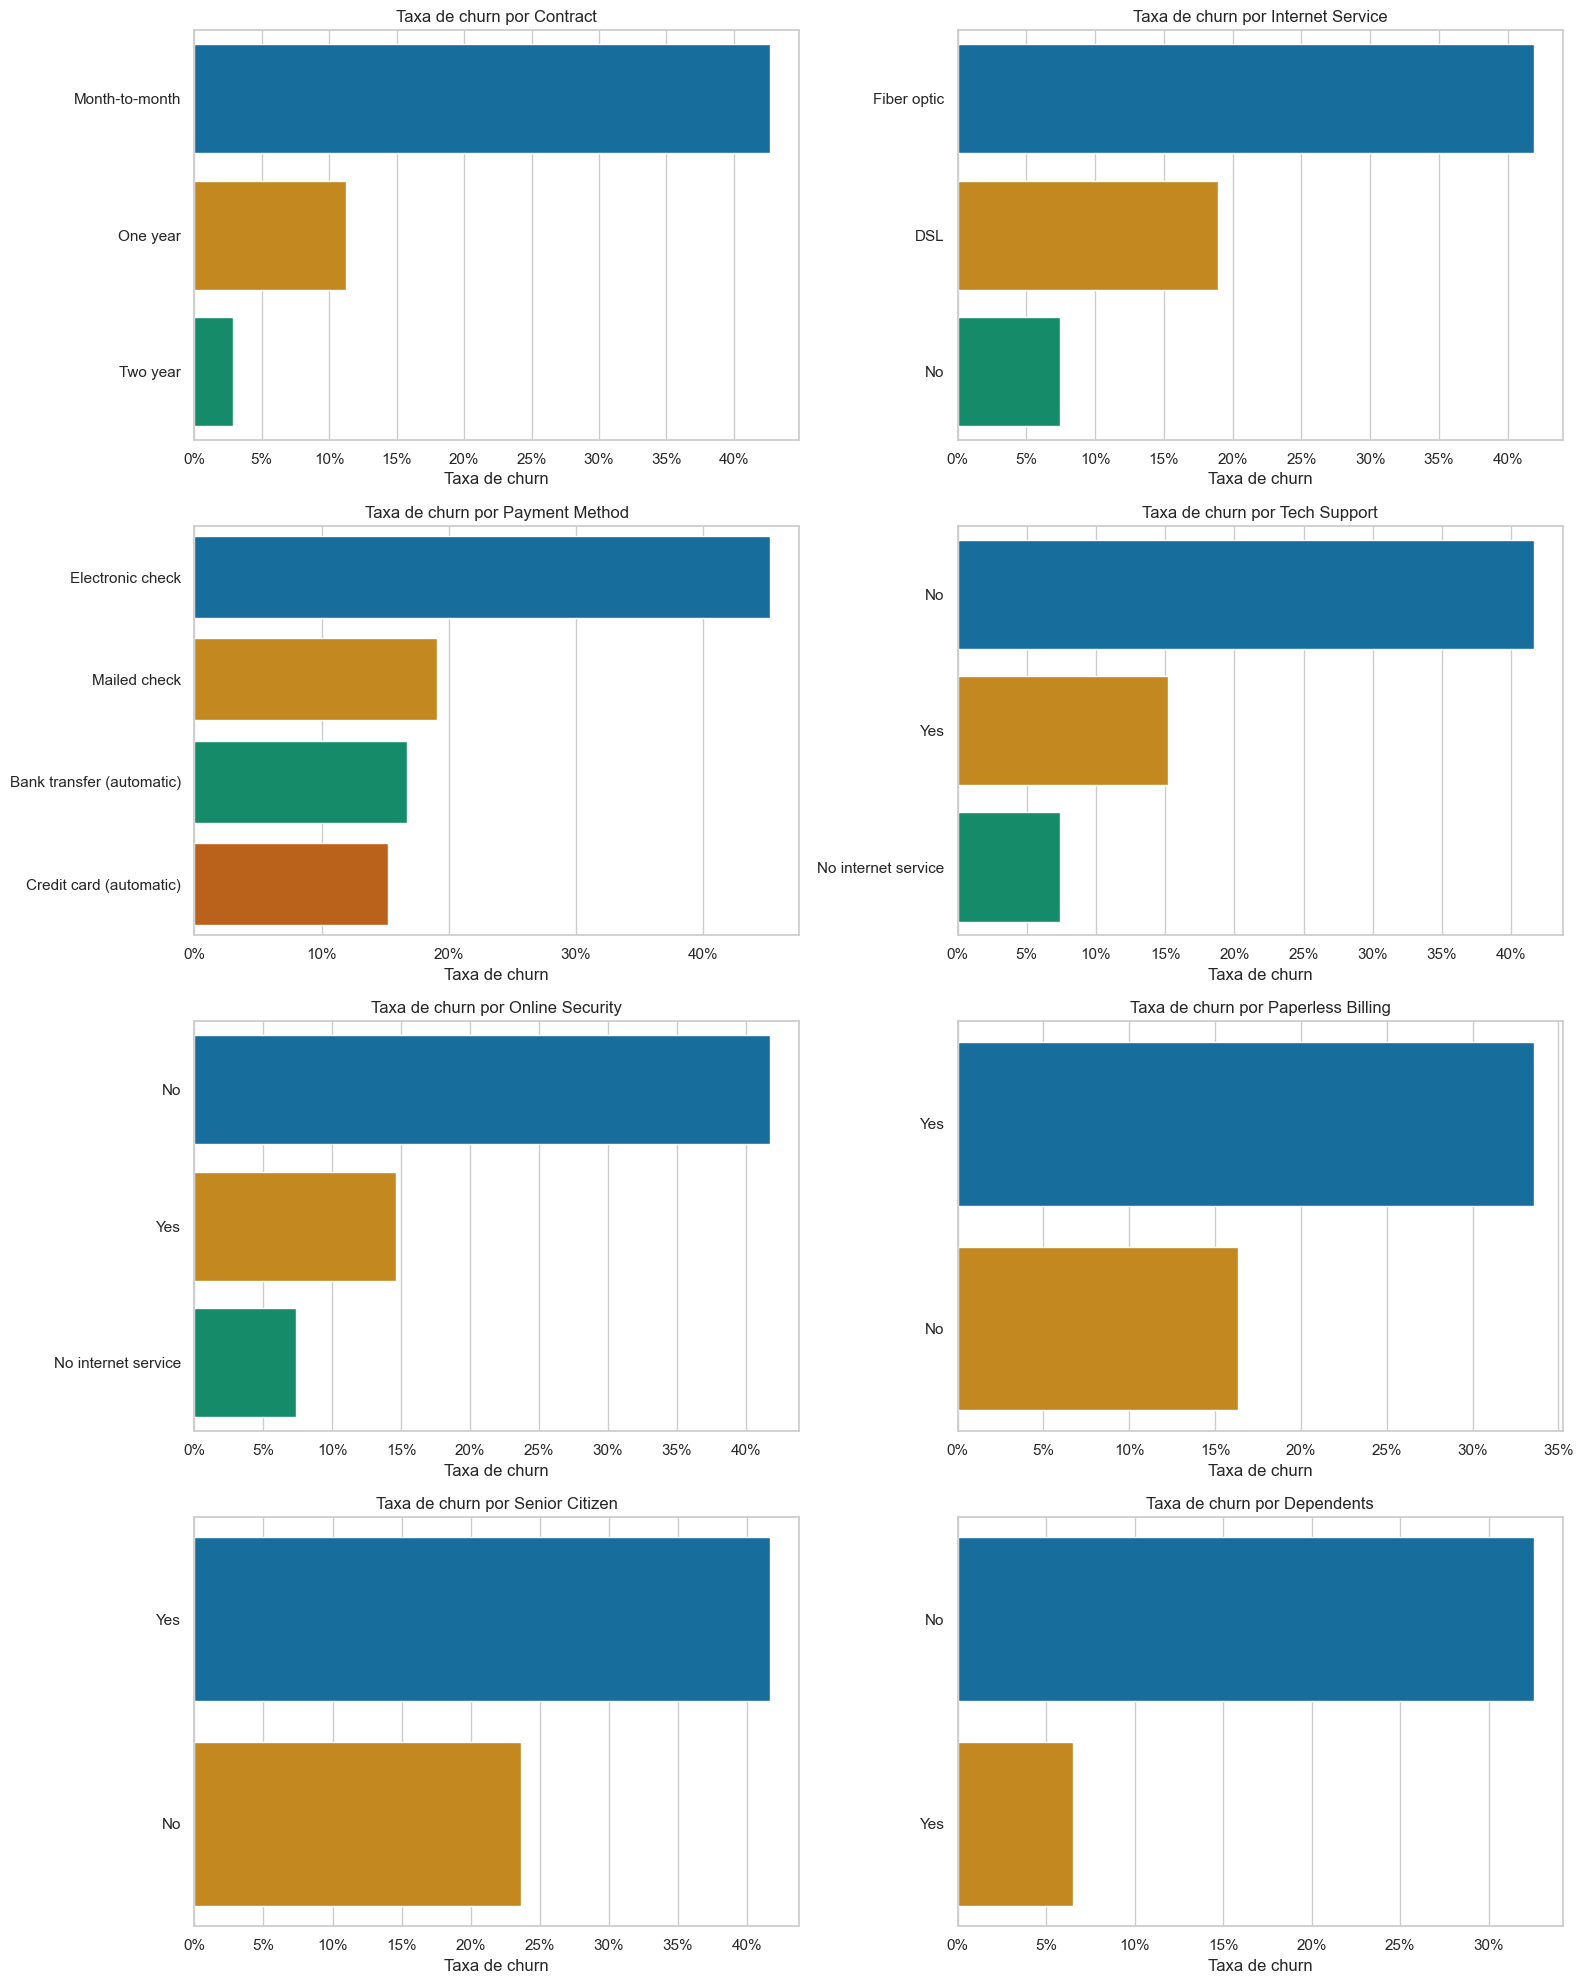

,Contract,clientes,taxa_churn,taxa_churn_pct
0,Month-to-month,3875,0.427097,42.71
1,One year,1473,0.112695,11.27
2,Two year,1695,0.028319,2.83


,Internet Service,clientes,taxa_churn,taxa_churn_pct
0,Fiber optic,3096,0.418928,41.89
1,DSL,2421,0.189591,18.96
2,No,1526,0.074050,7.40


,Payment Method,clientes,taxa_churn,taxa_churn_pct
0,Electronic check,2365,0.452854,45.29
1,Mailed check,1612,0.191067,19.11
2,Bank transfer (automatic),1544,0.167098,16.71
3,Credit card (automatic),1522,0.152431,15.24


In [6]:
categorical_features = [
    "Contract",
    "Internet Service",
    "Payment Method",
    "Tech Support",
    "Online Security",
    "Paperless Billing",
    "Senior Citizen",
    "Dependents",
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
category_tables = {}
for feature, axis in zip(categorical_features, axes.flat, strict=True):
    rates = (
        df.groupby(feature, observed=False)[TARGET_COLUMN]
        .agg(clientes="size", taxa_churn="mean")
        .sort_values("taxa_churn", ascending=False)
        .reset_index()
    )
    rates["taxa_churn_pct"] = rates["taxa_churn"].mul(100).round(2)
    category_tables[feature] = rates
    sns.barplot(data=rates, x="taxa_churn", y=feature, hue=feature, legend=False, ax=axis)
    axis.set(title=f"Taxa de churn por {feature}", xlabel="Taxa de churn", ylabel="")
    axis.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
fig.tight_layout()
plt.show()

display(category_tables["Contract"])
display(category_tables["Internet Service"])
display(category_tables["Payment Method"])

## Ordem das linhas e risco de divisão incorreta

O dataset está agrupado pelo alvo: clientes com churn aparecem antes dos clientes sem churn. Portanto, não se deve separar treino e teste por posição. A modelagem deve embaralhar os dados e usar validação cruzada estratificada.

In [7]:
target_transitions = df["Churn Label"].ne(df["Churn Label"].shift()).sum()
display(pd.DataFrame({
    "primeiro_alvo": [df["Churn Label"].iloc[0]],
    "ultimo_alvo": [df["Churn Label"].iloc[-1]],
    "blocos_de_alvo": [int(target_transitions)],
}))

,primeiro_alvo,ultimo_alvo,blocos_de_alvo
0,Yes,No,2


## Colunas a excluir ou tratar antes da modelagem

- **Vazamento direto:** `Churn Label`, `Churn Score` e `Churn Reason` são conhecidos a partir ou depois do churn. `Churn Value` será somente o alvo.
- **Identificadores:** `CustomerID` não representa comportamento generalizável.
- **Constantes:** `Count`, `Country` e `State` não adicionam poder preditivo neste recorte.
- **Geografia redundante/alta cardinalidade:** `City`, `Zip Code`, `Lat Long`, `Latitude` e `Longitude` exigem justificativa e validação específica; inicialmente devem ser removidas para evitar memorização geográfica.
- **Ausentes:** os 11 valores vazios de `Total Charges` correspondem a clientes com `Tenure Months = 0`; podem ser imputados no pipeline sem remover linhas.
- **Validação:** usar `StratifiedKFold` com embaralhamento e seed fixa. O dataset não deve ser dividido sequencialmente.

## Principais achados

- O dataset possui **7.043 clientes e 33 colunas**, sem linhas nem IDs duplicados.
- A taxa geral de churn é de aproximadamente **26,5%**, indicando desbalanceamento moderado.
- Contratos mensais, internet por fibra óptica e pagamento por cheque eletrônico apresentam as maiores taxas de churn.
- Clientes que saíram possuem, em média, menor tempo de permanência e maior cobrança mensal.
- Ausência de suporte técnico e segurança online está associada a churn mais alto, sem implicar causalidade.
- As associações são exploratórias; efeitos de confusão e vieses deverão ser documentados no Model Card.